<a href="https://colab.research.google.com/github/codewithtrisha09/ML-LAB/blob/main/WEEK_08_KNN_AND_ID3_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questions
Q-1. A Classification of Fruits
You are provided with a dataset of fruits. Each fruit is characterized by two features: weight (in grams) and
sweetness level (on a scale of 1 to 10). You want to classify a new fruit as either an "Apple" or an "Orange"
based on these features using the KNN algorithm.

Tasks:
1.Implement the KNN algorithm manually with k=3 to classify a new fruit with a weight of 165 grams
and sweetness level of 5.5.
2.Calculate the Euclidean, Manhattan, and Minkowski distances between the new fruit and all the
existing fruits in the dataset. Finally compare the calculated distances.
3.Based on the k-nearest neighbors, determine the label for the new fruit.
4.What is the effect of choosing different values of k (e.g., k=1, k=5) on the classification result?
5.Implement the above using function python program without using scikit learn library.
6.Plot the given samples, the Apple in Red color and the Orange in orange color. Also draw the
decision boundary.

Q-1. B Classification of Fruits
Implement the Python code for Q-1. A using the scikit-learn library. Plot the given samples, using red for
"Apple" and orange for "Orange." Also, plot the decision boundary. Calculate the distances using Euclidean,
Manhattan, and Minkowski metrics, and compare the results

Q1-A

In [ ]:
import math
dataset = [
    {"id": 1, "weight": 180, "sweetness": 7, "label": "Apple"},
    {"id": 2, "weight": 200, "sweetness": 6, "label": "Apple"},
    {"id": 3, "weight": 150, "sweetness": 4, "label": "Orange"},
    {"id": 4, "weight": 170, "sweetness": 5, "label": "Orange"},
    {"id": 5, "weight": 160, "sweetness": 6, "label": "Apple"},
    {"id": 6, "weight": 140, "sweetness": 3, "label": "Orange"}]
def calculate_distances(new_point):
    results=[]
    for fruit in dataset:
        dw=fruit["weight"]-new_point[0]
        ds=fruit["sweetness"]-new_point[1]
        euc=math.sqrt(dw**2+ds**2)
        man=abs(dw)+abs(ds)
        mink = (abs(dw)**3 + abs(ds)**3)**(1/3)
        results.append({
            "id": fruit["id"],"label":fruit["label"],
            "euclidean":euc,"manhattan":man,"minkowski":mink
        })
    return results

In [ ]:
def knn_classify(new_point,k=3):
    distances=calculate_distances(new_point)
    sorted_neigbours=sorted(distances,key=lambda x: x["euclidean"])
    neighbours=sorted_neighbours[:k]
    votes=[n["label"] for n in neighbours]
    prediction = max(set(votes), key=votes.count)
    return prediction, neighbours

new_fruit = (165, 5.5)
pred, neighbours = knn_classify(new_fruit, k=3)
print(f"Predicted Label (k=3): {pred}")

Predicted Label (k=3): Apple


In [ ]:
Q1-B

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import pairwise_distances

X = np.array([[180, 7], [200, 6], [150, 4], [170, 5], [160, 6], [140, 3]])
y = np.array([0, 0, 1, 1, 0, 1])
target = np.array([[165, 5.5]])

for m in ['euclidean', 'manhattan', 'minkowski']:
    kwargs = {'p': 3} if m == 'minkowski' else {}
    dists = pairwise_distances(X, target, metric=m, **kwargs).flatten()
    print(f"{m.capitalize()} distances: {np.round(dists, 4)}")



Scikit-Learn Prediction (k=3): Orange


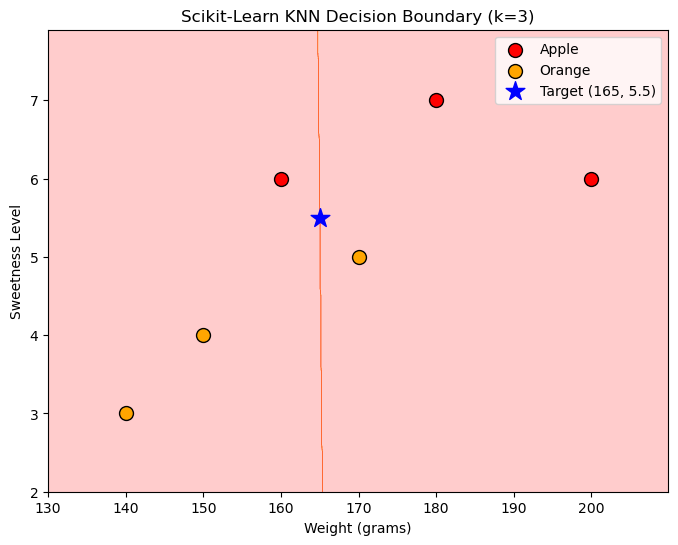

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)
pred_class = knn.predict(target)
label_map = {0: "Apple", 1: "Orange"}
print(f"\nScikit-Learn Prediction (k=3): {label_map[pred_class[0]]}")
x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2, colors=['red', 'orange'])
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Apple', edgecolors='black', s=100)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='orange', label='Orange', edgecolors='black', s=100)
plt.scatter(target[0, 0], target[0, 1], color='blue', marker='*', s=200, label='Target (165, 5.5)')

plt.title('Scikit-Learn KNN Decision Boundary (k=3)')
plt.xlabel('Weight (grams)')
plt.ylabel('Sweetness Level')
plt.legend()
plt.show()

Q-2. A Medical Diagnosis Decision
A dataset is provided to classify patients as "Healthy" or "Sick" based on their Age, Blood Pressure, and
Cholesterol levels.
Tasks:
1.Calculate the entropy for the target variable (Diagnosis).
2.Calculate the information gain for each feature (Age, Blood Pressure, Cholesterol).3. Using the ID3 algorithm, decide which feature should be chosen as the root node for the decision
tree.
4.Build the decision tree and explain the first few splits.
5.Predict whether a 50-year-old patient with low blood pressure and normal cholesterol is healthy or
sick using the tree you built.
6.Implement the above using function python program without using scikit learn library.

Q-2. B Medical Diagnosis Decision
Implement the Python code for Q-2. A using the scikit-learn library. Using the ID3 algorithm, decide which
feature should be chosen as the root node for the decision tree. Build the decision tree and explain the first
few splits. Predict whether a 50-year-old patient with low blood pressure and normal cholesterol is healthy
or sick using the tree you built.

In [ ]:
import math

data = [
    {"Age": 30, "BP": "High", "Chol": "High", "Diag": "Sick"},
    {"Age": 45, "BP": "Low", "Chol": "Normal", "Diag": "Healthy"},
    {"Age": 50, "BP": "High", "Chol": "High", "Diag": "Sick"},
    {"Age": 35, "BP": "Low", "Chol": "Normal", "Diag": "Healthy"},
    {"Age": 60, "BP": "High", "Chol": "High", "Diag": "Sick"},
    {"Age": 55, "BP": "Low", "Chol": "Normal", "Diag": "Healthy"},
    {"Age": 40, "BP": "High", "Chol": "High", "Diag": "Sick"},
    {"Age": 25, "BP": "Low", "Chol": "Normal", "Diag": "Healthy"},
    {"Age": 65, "BP": "High", "Chol": "High", "Diag": "Sick"},
    {"Age": 45, "BP": "Low", "Chol": "Normal", "Diag": "Healthy"}
]
def calculate_entropy(subset):
    labels = [row["Diag"] for row in subset]
    if not labels: return 0
    total = len(labels)
    counts = {label: labels.count(label) for label in set(labels)}
    return -sum((c / total) * math.log2(c / total) for c in counts.values())
def calculate_info_gain(subset, feature):
    total_entropy = calculate_entropy(subset)
    total_count = len(subset)
    groups = {}
    for row in subset:
        groups.setdefault(row[feature], []).append(row)
    weighted_entropy = sum((len(g) / total_count) * calculate_entropy(g) for g in groups.values())
    return total_entropy - weighted_entropy
print(f"Target Base Entropy: {calculate_entropy(data):.4f}")
print(f"Information Gain for BP: {calculate_info_gain(data, 'BP'):.4f}")
print(f"Information Gain for Cholesterol: {calculate_info_gain(data, 'Chol'):.4f}")


Target Base Entropy: 1.0000
Information Gain for BP: 1.0000
Information Gain for Cholesterol: 1.0000


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder
X = np.array([[30,0,0],
              [45,1,1],
              [50,0,0],
              [35,1,1],
              [60,0,0],
              [55,1,1],
              [40,0,0],
              [25,1,1],
              [65,0,0],[45, 1, 1]

])
y = np.array(["Sick", "Healthy", "Sick", "Healthy", "Sick", "Healthy", "Sick", "Healthy", "Sick", "Healthy"])
clf = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf.fit(X, y)
tree_rules = export_text(clf, feature_names=["Age", "Blood_Pressure", "Cholesterol"])
print("Scikit-Learn Tree Rules:\n", tree_rules)
test_patient = np.array([[50, 1, 1]])
pred = clf.predict(test_patient)
print(f"Prediction for test profile: {pred[0]}")


Scikit-Learn Tree Rules:
 |--- Blood_Pressure <= 0.50
|   |--- class: Sick
|--- Blood_Pressure >  0.50
|   |--- class: Healthy

Prediction for test profile: Healthy


ADDITIONAL

1. We have data from the questionnaires survey (to ask people opinion) and objective testing with two
attributes (acid durability and strength) to classify whether a special paper tissue is good or not. Here is four
training samples as follows. Apply the K-nearest neighbour’s (KNN) algorithm when K=2, 3 and 4 to classify
an instance (3, 7) as good or bad.

Implement the above using python code without using scikit learn library. Plot the given samples Bad in Red
color and Good in green color. Also draw the decision boundary. Calculate the desistance using Euclidean,
Manhattan, and Minkowski and compare.
2. Implement the Question number 1 with using scikit learn library. Plot the given samples Bad in Red color
and Good in green color. Also plot the decision boundary. Calculate the desistance using Euclidean,
Manhattan, and Minkowski and compare the results.
3.There is a Car manufacturer company that has manufactured a new SUV car. The company wants to give
the ads to the users who are interested in buying that SUV. So for this problem, we have a dataset that contains
multiple user's information through the social network. The dataset contains lots of information but the
Estimated Salary and Age we will consider for the independent variable and the Purchased variable is for the
dependent variable. Below is the dataset:
1. Apply the K-NN algorithm when K=2, 3 and 4 to classify purchased or not. Calculate the desistance
using Euclidean, Manhattan, and Minkowski and compare.
2. Test your developed K-NN without and with using Scikit Learn Library.
3. Plot the Yellow points are for Purchased(1) and Green Points for not Purchased(0) variable.
4. Show the graph has to classify users in the correct categories, as most of the users who didn't buy the
SUV are in the red region, and users who bought the SUV are in the green region.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
X = np.array([[7,7], [7,4], [3,4], [1,4], [4,5], [3,5], [4,6], [8,7], [7,9], [8,8]])
y = np.array(['Bad', 'Bad', 'Good', 'Good', 'Bad', 'Good', 'Bad', 'Bad', 'Good', 'Bad'])
target = np.array([3, 7])

def manual_knn(X_train, y_train, test_point, k):
    dists = np.sqrt(np.sum((X_train - test_point)**2, axis=1))
    nearest_indices = np.argsort(dists)[:k]
    nearest_labels = y_train[nearest_indices]

    unique_labels, counts = np.unique(nearest_labels, return_counts=True)
    return unique_labels[np.argmax(counts)]
for k_val in [2, 3, 4]:
    print(f"Manual KNN Prediction for K={k_val}: {manual_knn(X, y, target, k_val)}")


Manual KNN Prediction for K=2: Bad
Manual KNN Prediction for K=3: Bad
Manual KNN Prediction for K=4: Bad


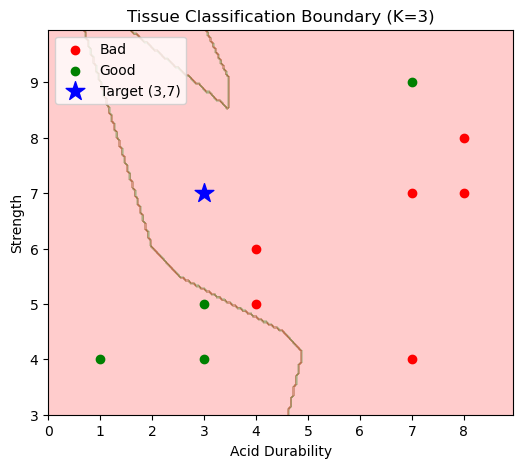

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_numeric = le.fit_transform(y)
knn_model = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_model.fit(X, y_numeric)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.2, colors=['red', 'green'])
plt.scatter(X[y_numeric==0, 0], X[y_numeric==0, 1], color='red', label='Bad')
plt.scatter(X[y_numeric==1, 0], X[y_numeric==1, 1], color='green', label='Good')
plt.scatter(target[0], target[1], color='blue', marker='*', s=200, label='Target (3,7)')

plt.title('Tissue Classification Boundary (K=3)')
plt.xlabel('Acid Durability')
plt.ylabel('Strength')
plt.legend()
plt.show()


Euclidean pair matrix computed successfully.
Manhattan pair matrix computed successfully.
Minkowski pair matrix computed successfully.


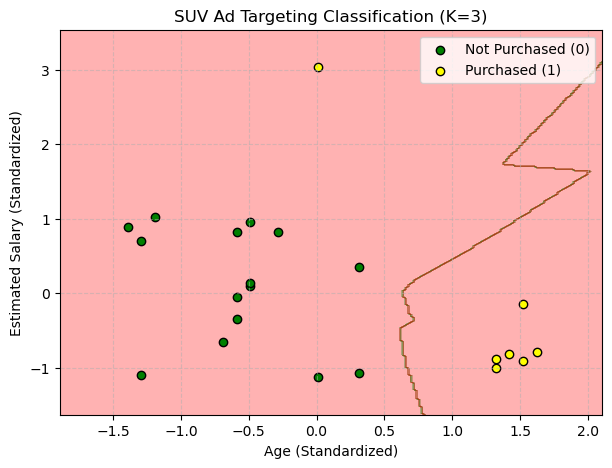

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
data_matrix = [
    [19, 19000, 0], [35, 20000, 0], [26, 43000, 0], [27, 57000, 0],
    [19, 76000, 0], [27, 58000, 0], [27, 84000, 0], [32, 150000, 1],
    [25, 33000, 0], [35, 65000, 0], [26, 80000, 0], [26, 52000, 0],
    [20, 86000, 0], [32, 18000, 0], [18, 82000, 0], [29, 80000, 0],
    [47, 25000, 1], [45, 26000, 1], [46, 28000, 1], [48, 29000, 1],
    [45, 22000, 1], [47, 49000, 1]
]
df = pd.DataFrame(data_matrix, columns=['Age', 'EstimatedSalary', 'Purchased'])
X_suv = df[['Age', 'EstimatedSalary']].values
y_suv = df['Purchased'].values
for metric in ['euclidean', 'manhattan', 'minkowski']:
    kwargs = {'p': 3} if metric == 'minkowski' else {}
    d_mat = pairwise_distances(X_suv, metric=metric, **kwargs)
    print(f"{metric.capitalize()} pair matrix computed successfully.")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_suv)
knn_suv = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_suv.fit(X_scaled, y_suv)
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z_suv = knn_suv.predict(np.c_[xx.ravel(), yy.ravel()])
Z_suv = Z_suv.reshape(xx.shape)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z_suv, alpha=0.3, colors=['red', 'green'])
plt.scatter(X_scaled[y_suv == 0, 0], X_scaled[y_suv == 0, 1], color='green', label='Not Purchased (0)', edgecolors='k')
plt.scatter(X_scaled[y_suv == 1, 0], X_scaled[y_suv == 1, 1], color='yellow', label='Purchased (1)', edgecolors='k')
plt.title('SUV Ad Targeting Classification (K=3)')
plt.xlabel('Age (Standardized)')
plt.ylabel('Estimated Salary (Standardized)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
